# Customer Churn Analysis — ABC Communications Ltd
### AnalystLab Africa | Data Analytics Internship Programme — Week 1
**Analyst:** Junior Data Analyst, AnalystLab Africa Consulting
**Client:** ABC Communications Ltd
**Objective:** Investigate customer churn drivers and deliver business insights to support retention strategy.

---
## Part 2 — Data Loading & Inspection


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape

(7043, 21)

The dataset contains **7,043 customer records** and **21 columns** (features + target `Churn`).

In [2]:
df.head()

  customerID  gender  SeniorCitizen Partner Dependents  tenure  ... MonthlyCharges TotalCharges Churn
0 7590-VHVEG  Female              0     Yes         No       1  ...          29.85        29.85    No
1 5575-GNVDE    Male              0      No         No      34  ...          56.95       1889.5    No
2 3668-QPYBK    Male              0      No         No       2  ...          53.85       108.15   Yes
3 7795-CFOCW    Male              0      No         No      45  ...          42.30      1840.75    No
4 9237-HQITU  Female              0      No         No       2  ...          70.70       151.65   Yes


In [3]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges       float64
TotalCharges          object   <-- should be numeric, stored as text
Churn                object
dtype: object


In [4]:
# Missing values
df.isnull().sum().sum()

0   # no NaNs reported at face value

**But this is misleading.** `TotalCharges` is stored as *text*, not numeric. Converting it forces 11 blank strings to reveal themselves as true missing values.

In [5]:
# Duplicate check
print("Duplicate customerIDs:", df['customerID'].duplicated().sum())
print("Fully duplicated rows:", df.duplicated().sum())

Duplicate customerIDs: 0
Fully duplicated rows: 0


In [6]:
# TotalCharges cleanup
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Missing TotalCharges after conversion:", df['TotalCharges'].isna().sum())
df.loc[df['TotalCharges'].isna(), ['customerID','tenure','MonthlyCharges','TotalCharges']]

Missing TotalCharges after conversion: 11


     customerID  tenure  MonthlyCharges  TotalCharges
488  4472-LVYGI       0           52.55           NaN
753  3115-CZMZD       0           20.25           NaN
936  5709-LVOEQ       0           80.85           NaN
1082 4367-NUYAO       0           25.75           NaN
1340 1371-DWPAZ       0           56.05           NaN
3331 7644-OMVMY       0           19.85           NaN
3826 3213-VVOLG       0           25.35           NaN
4380 2520-SGTTA       0           20.00           NaN
5218 2923-ARZLG       0           19.70           NaN
6670 4075-WKNIU       0           73.35           NaN
6754 2775-SEFEE       0           61.90           NaN


All 11 blanks belong to customers with **`tenure = 0`** — brand-new customers who have not yet been billed a full cycle. This is logically consistent (`TotalCharges ≈ tenure × MonthlyCharges`), so it is **not random noise or a data error** — it's a structural artefact of new signups. We fill these with `0` rather than dropping the rows, since dropping would bias the "new customer" segment out of the analysis.

In [7]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Summary statistics — numeric fields
df[['tenure','MonthlyCharges','TotalCharges']].describe().round(2)

         tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     32.37           64.76       2279.73
std      24.56           30.09       2266.79
min       0.00           18.25          0.00
25%       9.00           35.50        398.55
50%      29.00           70.35       1394.55
75%      55.00           89.85       3786.60
max      72.00          118.75       8684.80


**Dataset Inspection Summary**

| Check | Result |
|---|---|
| Rows | 7,043 customers |
| Columns | 21 (19 features + `customerID` + `Churn` target) |
| Duplicate rows | 0 |
| Duplicate customer IDs | 0 |
| True missing values | 11 (`TotalCharges`, resolved — new customers, filled with 0) |
| Data type fix needed | `TotalCharges`: text → numeric |
| Target balance | 73.5% No / 26.5% Yes — moderately imbalanced |
| Tenure range | 0–72 months (mean ≈ 32) |
| Monthly charges range | $18.25–$118.75 (mean ≈ $64.76) |

The dataset is otherwise clean: no duplicate customers, no impossible values (negative charges/tenure), and all categorical fields have small, well-defined value sets (2–4 categories each).


---
## Part 3 — Business Data Analysis

Charts are grouped by business question. Each chart is followed by a short interpretation.

### Q1. What does the customer base look like?


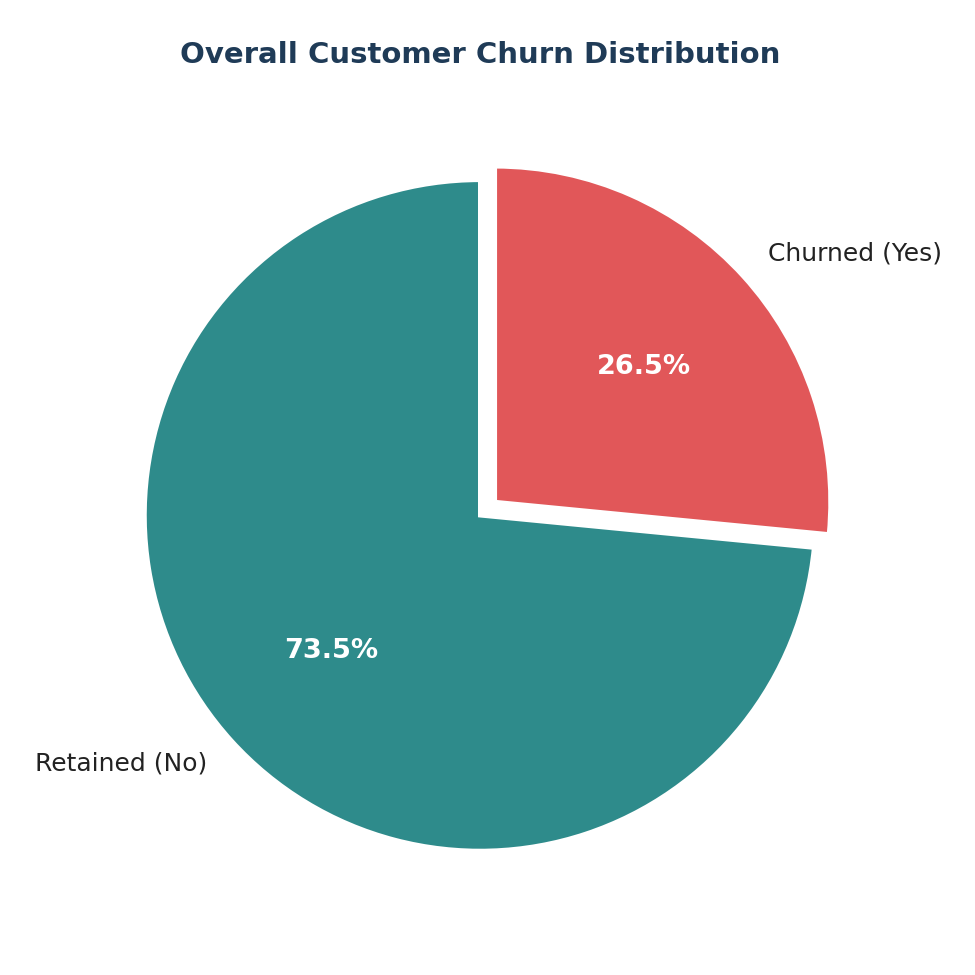

In [8]:
fig, ax = plt.subplots(figsize=(6.5,6.5))
vals = df['Churn'].value_counts()
ax.pie(vals, labels=['Retained (No)','Churned (Yes)'], autopct='%1.1f%%',
       colors=['#2E8B8B','#E15759'], startangle=90, explode=(0,0.06))
ax.set_title("Overall Customer Churn Distribution")
plt.show()

**Interpretation:** 26.5% of the customer base (1,869 of 7,043 customers) has churned — a meaningfully high rate for a subscription telecom business, confirming churn is a material threat to revenue.

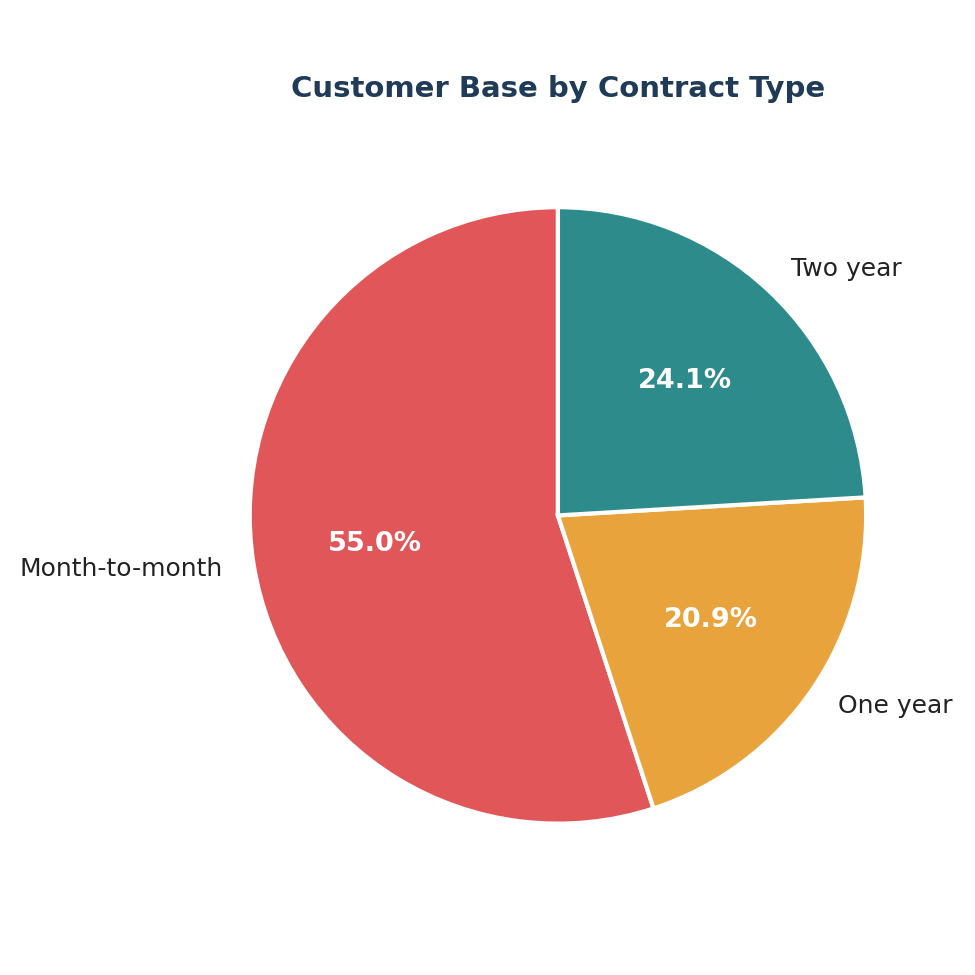

In [9]:
fig, ax = plt.subplots(figsize=(6.5,6.5))
vals = df['Contract'].value_counts().reindex(['Month-to-month','One year','Two year'])
ax.pie(vals, labels=vals.index, autopct='%1.1f%%', colors=['#E15759','#E8A33D','#2E8B8B'], startangle=90)
ax.set_title("Customer Base by Contract Type")
plt.show()

**Interpretation:** 55% of customers are on flexible **month-to-month** contracts — the segment with the least commitment and (as shown below) the highest churn risk. Only 24% are locked into two-year contracts.

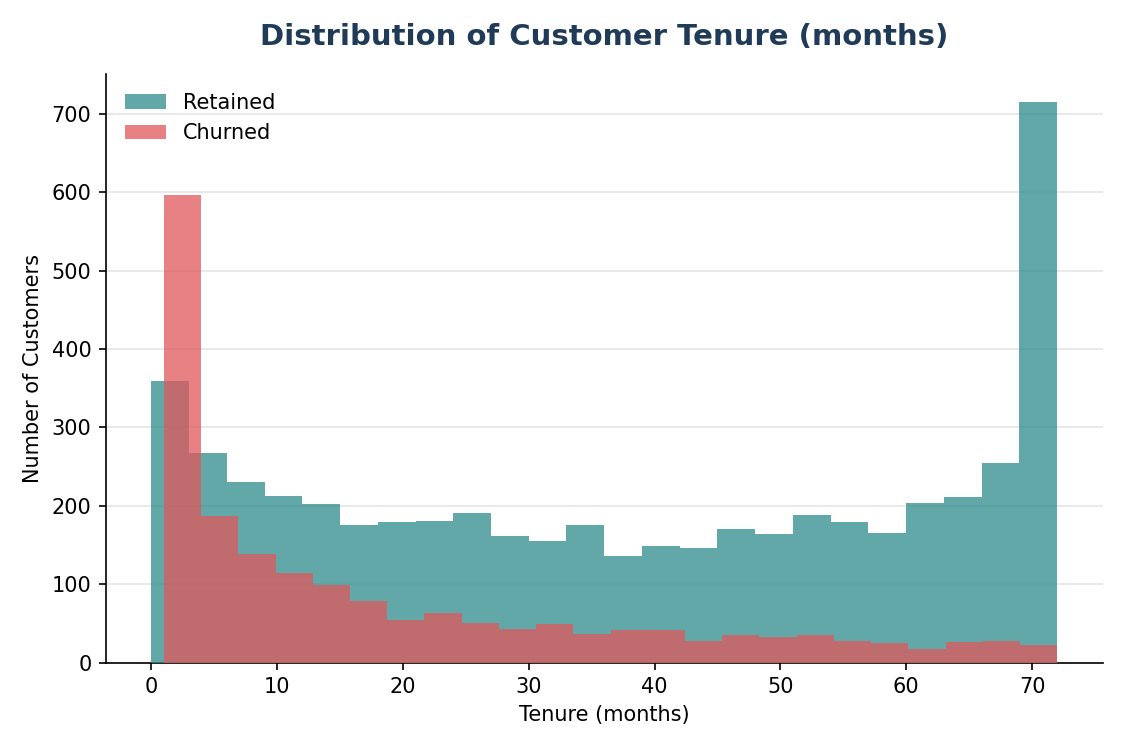

In [10]:
fig, ax = plt.subplots(figsize=(7.5,5))
ax.hist(df[df['Churn']=='No']['tenure'], bins=24, alpha=0.75, label='Retained', color='#2E8B8B')
ax.hist(df[df['Churn']=='Yes']['tenure'], bins=24, alpha=0.75, label='Churned', color='#E15759')
ax.set_title("Distribution of Customer Tenure (months)")
ax.set_xlabel("Tenure (months)"); ax.set_ylabel("Number of Customers"); ax.legend()
plt.show()

**Interpretation:** Tenure is bimodal — a large cluster of very new customers (0–5 months) and another large cluster near 70+ months (long-term loyalists). Churned customers (red) are heavily concentrated at low tenure, meaning **churn risk is front-loaded in the customer lifecycle**.

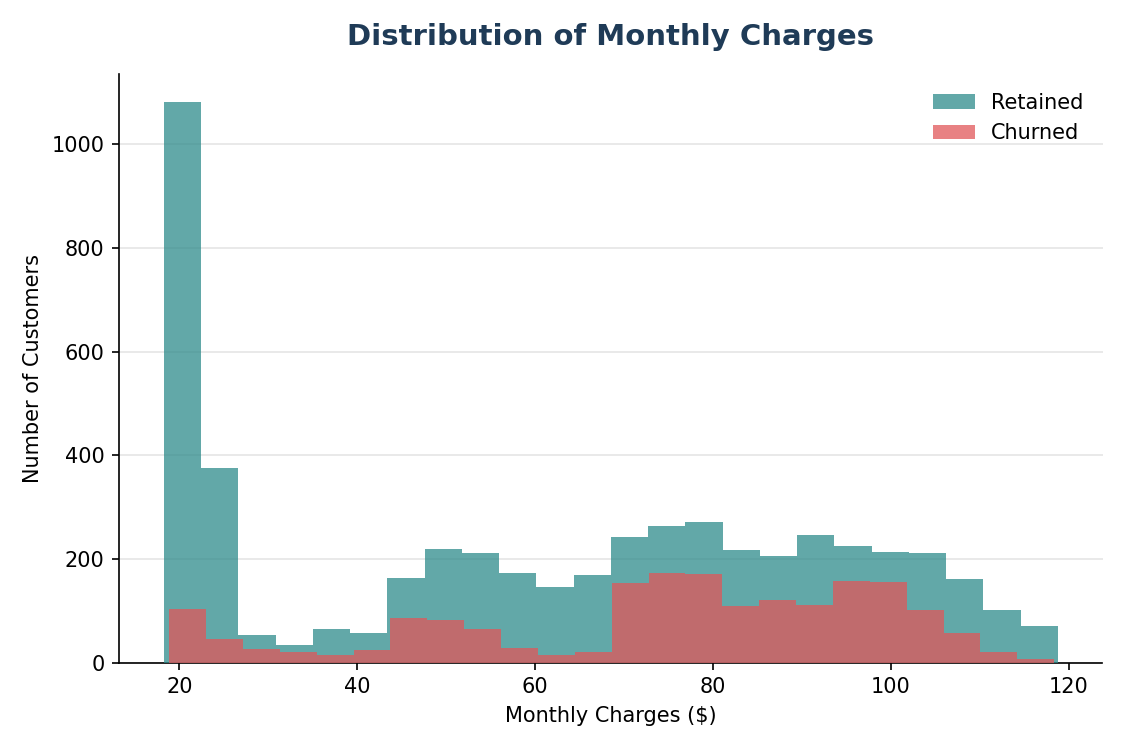

In [11]:
fig, ax = plt.subplots(figsize=(7.5,5))
ax.hist(df[df['Churn']=='No']['MonthlyCharges'], bins=24, alpha=0.75, label='Retained', color='#2E8B8B')
ax.hist(df[df['Churn']=='Yes']['MonthlyCharges'], bins=24, alpha=0.75, label='Churned', color='#E15759')
ax.set_title("Distribution of Monthly Charges")
ax.set_xlabel("Monthly Charges ($)"); ax.set_ylabel("Number of Customers"); ax.legend()
plt.show()

**Interpretation:** There's a large spike of low-bill customers (~$20, mostly no-internet/phone-only plans) who rarely churn, and churners are disproportionately concentrated in the **$70–$110** range — higher-priced plans (mainly fiber-optic subscribers).

### Q2 & Q3. Which segments churn most? Does contract type influence retention?

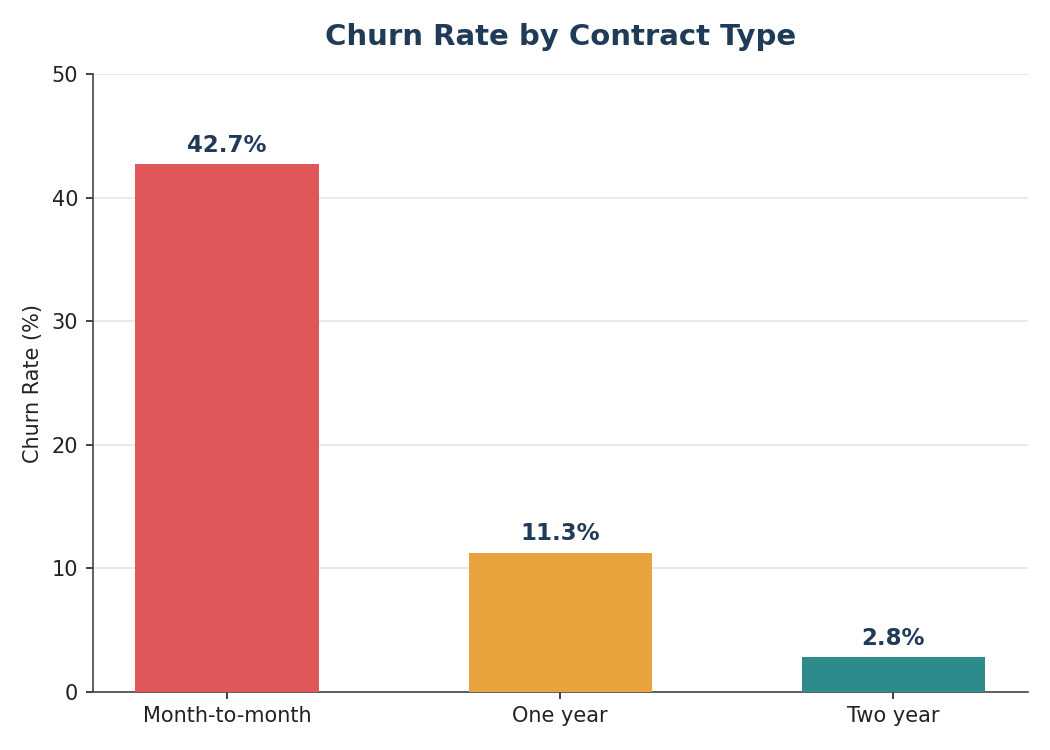

In [12]:
fig, ax = plt.subplots(figsize=(7,5))
ct = pd.crosstab(df['Contract'], df['Churn'], normalize='index')['Yes']*100
ct = ct.reindex(['Month-to-month','One year','Two year'])
bars = ax.bar(ct.index, ct.values, color=['#E15759','#E8A33D','#2E8B8B'])
for b,v in zip(bars, ct.values):
    ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.1f}%", ha='center', fontweight='bold')
ax.set_title("Churn Rate by Contract Type"); ax.set_ylabel("Churn Rate (%)"); ax.set_ylim(0,50)
plt.show()

**Interpretation:** Contract type is the **single strongest churn driver** in the dataset:
- Month-to-month: **42.7%** churn
- One year: **11.3%** churn
- Two year: **2.8%** churn

Moving a customer from month-to-month to even a one-year contract cuts churn risk by roughly 4x.

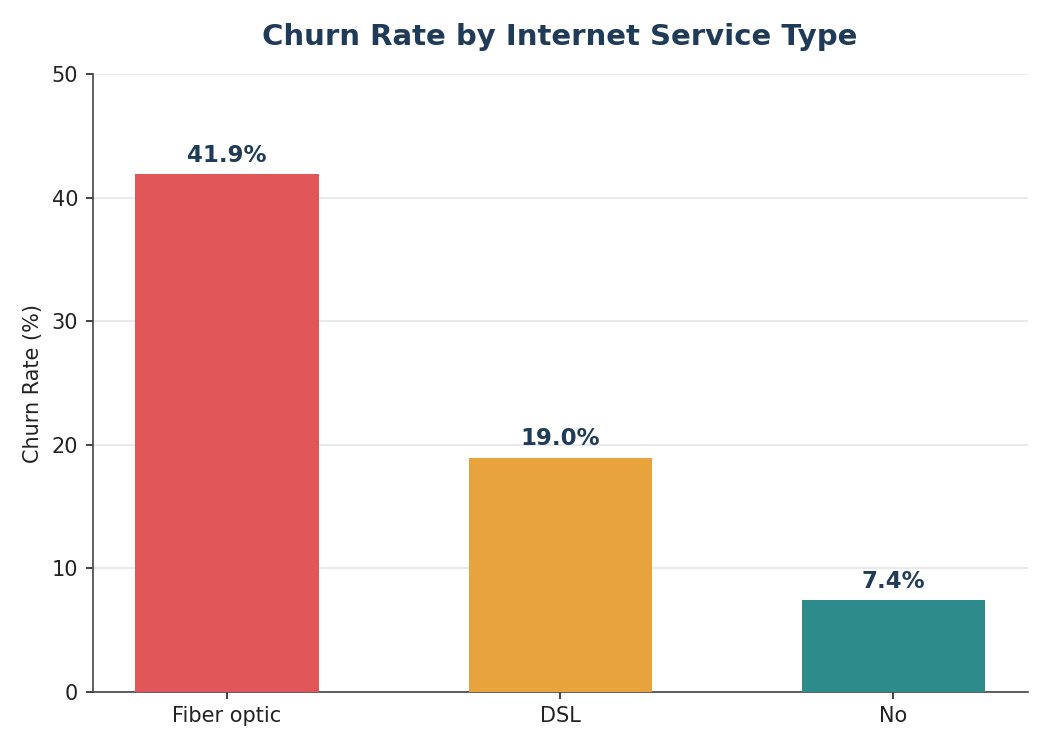

In [13]:
fig, ax = plt.subplots(figsize=(7,5))
ct = pd.crosstab(df['InternetService'], df['Churn'], normalize='index')['Yes']*100
ct = ct.reindex(['Fiber optic','DSL','No'])
bars = ax.bar(ct.index, ct.values, color=['#E15759','#E8A33D','#2E8B8B'])
for b,v in zip(bars, ct.values):
    ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.1f}%", ha='center', fontweight='bold')
ax.set_title("Churn Rate by Internet Service Type"); ax.set_ylabel("Churn Rate (%)"); ax.set_ylim(0,50)
plt.show()

**Interpretation:** Fiber-optic customers churn at **41.9%**, more than double DSL (19.0%) and nearly 6x customers with no internet service (7.4%). Despite being the premium product, fiber is the highest-risk segment — likely a pricing or service-quality issue rather than a product-appeal issue (fiber is still the most-subscribed service).

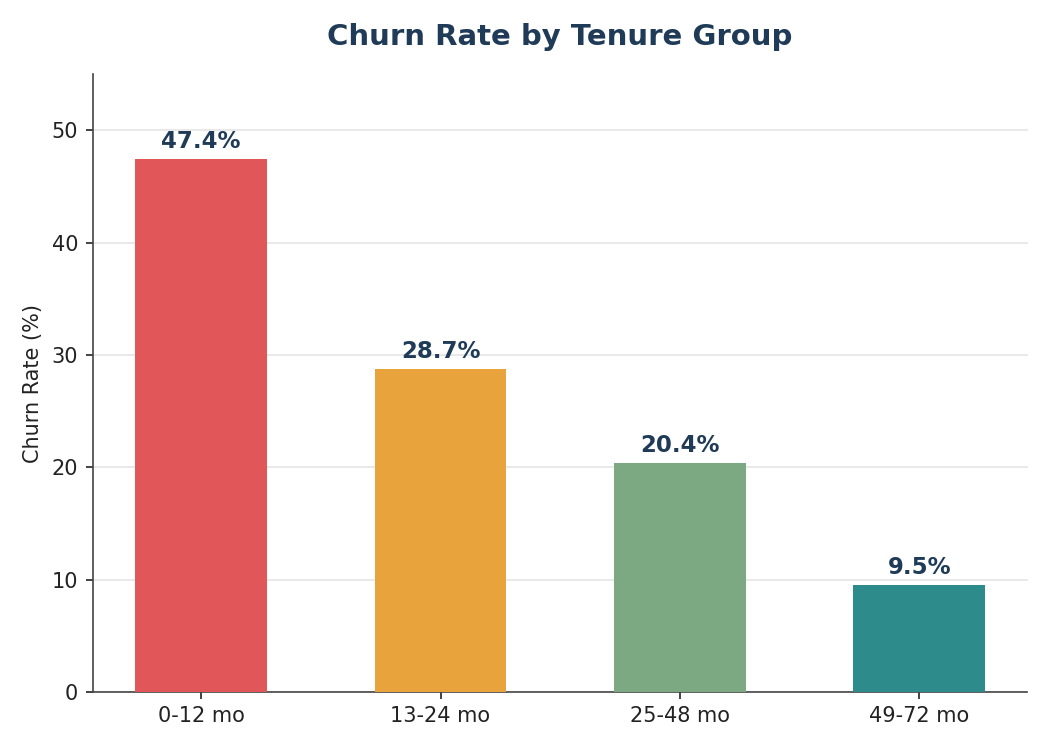

In [14]:
fig, ax = plt.subplots(figsize=(7,5))
ct = pd.crosstab(df['tenure_group'] if 'tenure_group' in df else pd.cut(df['tenure'], bins=[-1,12,24,48,72], labels=['0-12 mo','13-24 mo','25-48 mo','49-72 mo']),
                  df['Churn'], normalize='index')['Yes']*100
bars = ax.bar(ct.index.astype(str), ct.values, color=['#E15759','#E8A33D','#7CA982','#2E8B8B'])
for b,v in zip(bars, ct.values):
    ax.text(b.get_x()+b.get_width()/2, v+1, f"{v:.1f}%", ha='center', fontweight='bold')
ax.set_title("Churn Rate by Tenure Group"); ax.set_ylabel("Churn Rate (%)"); ax.set_ylim(0,55)
plt.show()

**Interpretation (Q4 — Does tenure affect loyalty?):** Yes, strongly and monotonically:
- 0–12 months: **47.4%** churn
- 13–24 months: **28.7%**
- 25–48 months: **20.4%**
- 49–72 months: **9.5%**

The first year is the danger zone. Customers who survive past month 12 become progressively 'stickier'.

### Q5. Which services influence churn? (add-on services)

In [15]:
for col in ['OnlineSecurity','TechSupport','OnlineBackup','DeviceProtection']:
    rate = df[df[col]=='No']['Churn'].eq('Yes').mean()*100
    print(f"{col} = 'No'  ->  churn rate {rate:.1f}%")

OnlineSecurity = 'No'  ->  churn rate 41.8%
TechSupport = 'No'  ->  churn rate 41.6%
OnlineBackup = 'No'  ->  churn rate 39.9%
DeviceProtection = 'No'  ->  churn rate 39.1%


**Interpretation:** Customers who lack security/support add-ons churn at roughly **2.5–3x** the rate of those who have them (OnlineSecurity: 41.8% vs 14.6%; TechSupport: 41.6% vs 15.2%). These "protective" services correlate strongly with retention — likely because they increase switching cost and perceived value, and because customers without tech support have more unresolved friction.

### Q6. Which payment methods have higher churn?

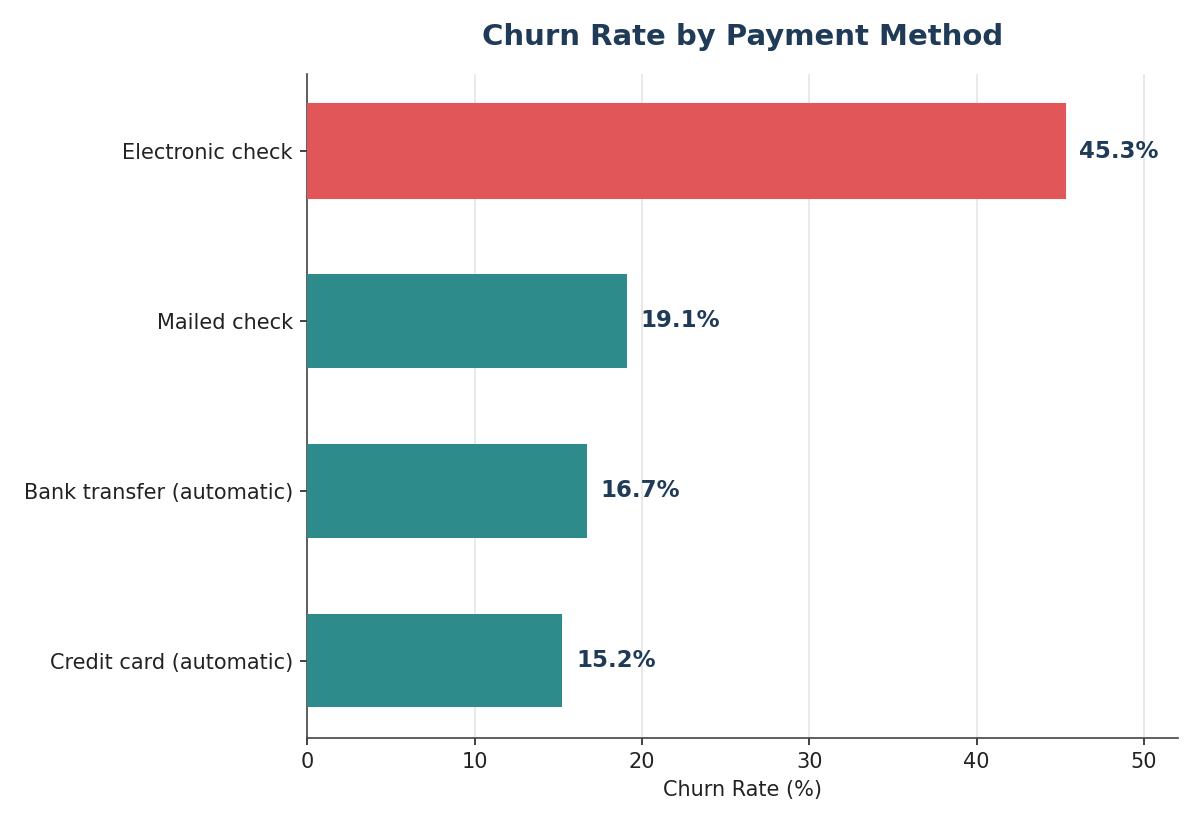

In [16]:
fig, ax = plt.subplots(figsize=(8,5.5))
ct = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')['Yes']*100
ct = ct.sort_values(ascending=True)
bars = ax.barh(ct.index, ct.values, color='#2E8B8B')
bars[-1].set_color('#E15759')
for b,v in zip(bars, ct.values):
    ax.text(v+0.8, b.get_y()+b.get_height()/2, f"{v:.1f}%", va='center', fontweight='bold')
ax.set_title("Churn Rate by Payment Method"); ax.set_xlabel("Churn Rate (%)")
plt.show()

**Interpretation:** **Electronic check** users churn at **45.3%** — roughly 3x the rate of automatic payment methods (credit card 15.2%, bank transfer 16.7%, mailed check 19.1%). Electronic check is a manual, no-commitment payment method, and it's also the most common method among month-to-month customers — the two risk factors compound.

### Distribution shape and outliers

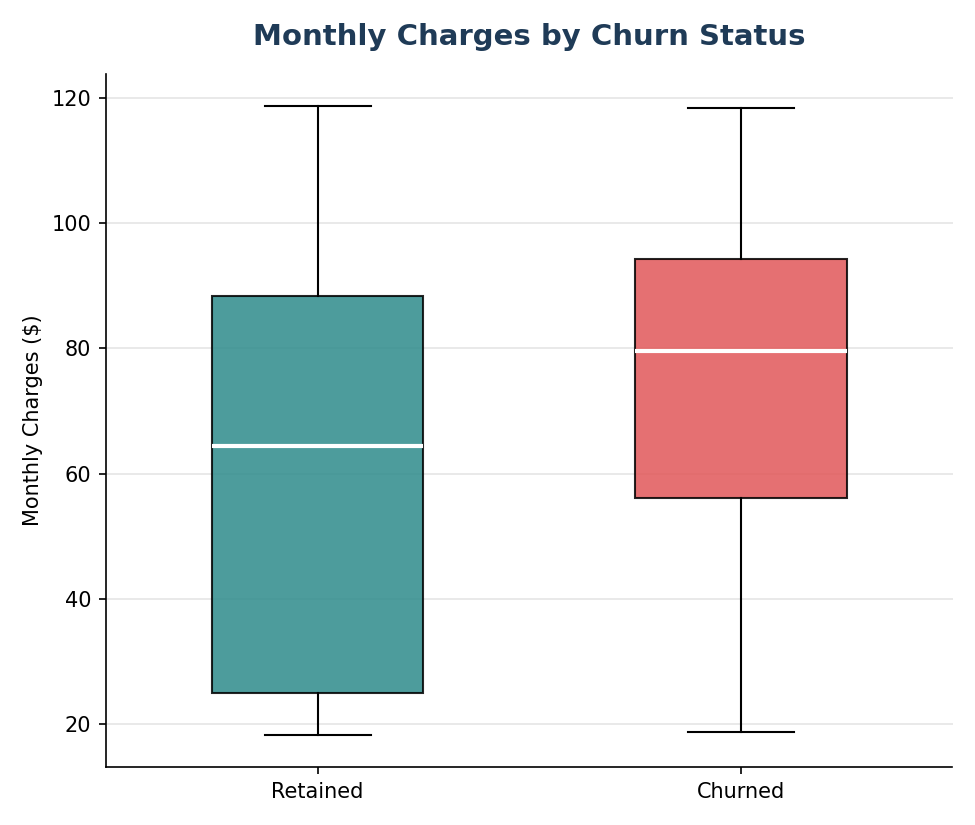

In [17]:
fig, ax = plt.subplots(figsize=(6.5,5.5))
data = [df[df['Churn']=='No']['MonthlyCharges'], df[df['Churn']=='Yes']['MonthlyCharges']]
bp = ax.boxplot(data, tick_labels=['Retained','Churned'], patch_artist=True, widths=0.5)
for patch, color in zip(bp['boxes'], ['#2E8B8B','#E15759']):
    patch.set_facecolor(color)
ax.set_title("Monthly Charges by Churn Status"); ax.set_ylabel("Monthly Charges ($)")
plt.show()

**Interpretation:** Churned customers have a visibly higher median monthly bill (~$79) than retained customers (~$64), and their interquartile range sits at a higher price band overall. There are no extreme outliers in either group — the difference is a genuine distributional shift, not a few high-spenders skewing the average.

In [18]:
df.groupby('Churn')[['tenure','MonthlyCharges','TotalCharges']].mean().round(2)

        tenure  MonthlyCharges  TotalCharges
Churn
No       37.57           61.27       2555.34
Yes      17.98           74.44       1531.80


### Correlation Heatmap

In [19]:
dfc = df.copy()
dfc['Churn_num'] = (dfc['Churn']=='Yes').astype(int)
dfc['Partner_num'] = (dfc['Partner']=='Yes').astype(int)
dfc['Dependents_num'] = (dfc['Dependents']=='Yes').astype(int)
dfc['PaperlessBilling_num'] = (dfc['PaperlessBilling']=='Yes').astype(int)
corr_cols = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen','Partner_num','Dependents_num','PaperlessBilling_num','Churn_num']
corr = dfc[corr_cols].corr().round(2)
corr

                 tenure  MonthlyCharges  TotalCharges  SeniorCitizen  Partner_num  Dependents_num  PaperlessBilling_num  Churn_num
tenure             1.00            0.25          0.83           0.02         0.38            0.16                  0.01     -0.35
MonthlyCharges     0.25            1.00          0.65           0.10         0.10           -0.11                  0.35      0.19
TotalCharges       0.83            0.65          1.00           0.32         0.32            0.06                  0.16     -0.20
SeniorCitizen      0.02            0.10          0.32           1.00         0.02           -0.21                  0.16      0.15
Partner_num        0.38            0.10          0.32           0.02         1.00            0.45                 -0.01     -0.15
Dependents_num     0.16           -0.11          0.06          -0.21         0.45            1.00                 -0.11     -0.16
PaperlessBilling_num 0.01          0.35          0.16           0.16        -0.01        

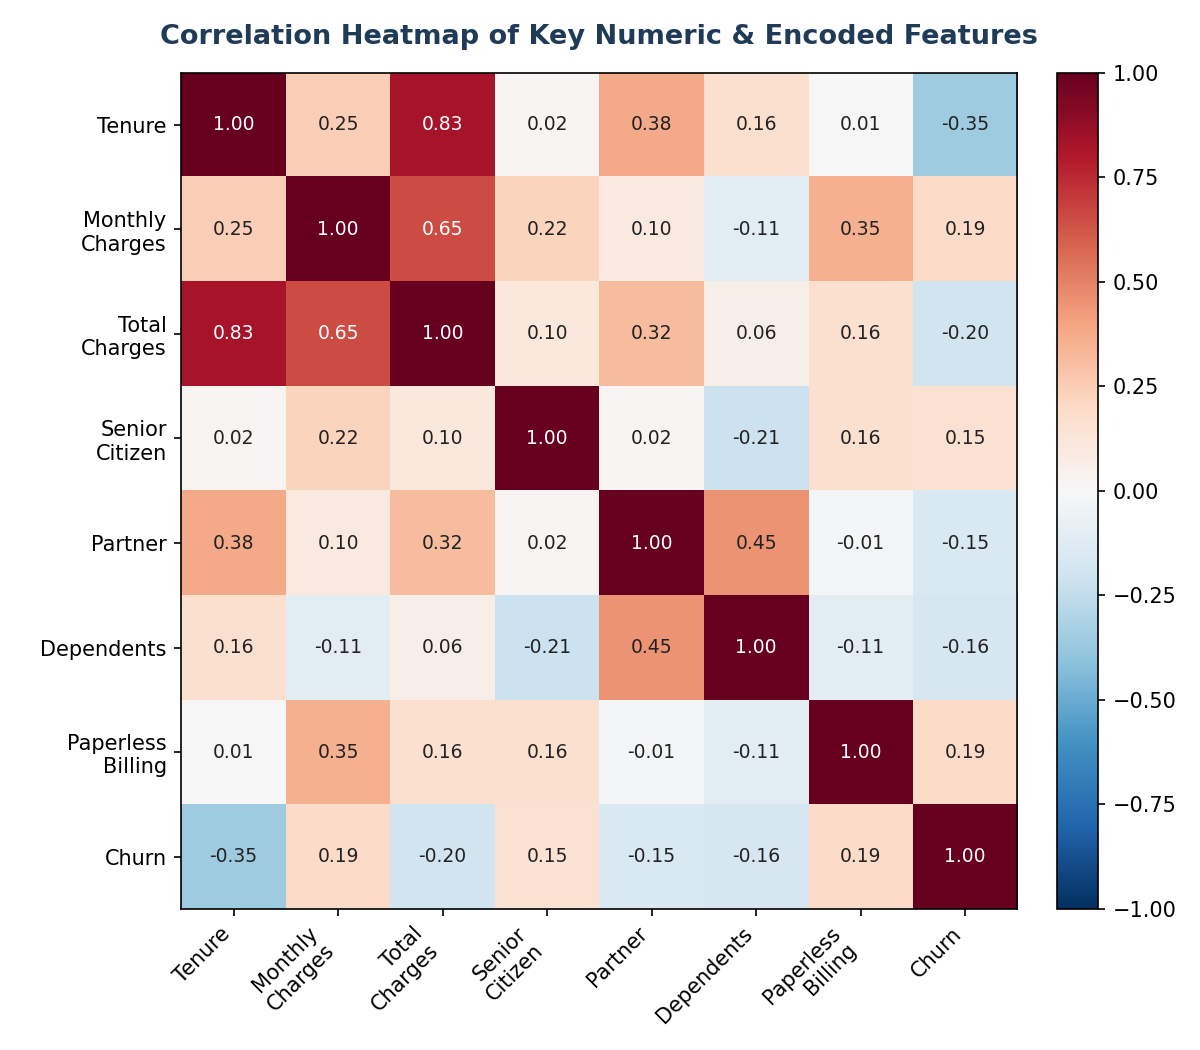

In [20]:
fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
labels = ['Tenure','Monthly\nCharges','Total\nCharges','Senior\nCitizen','Partner','Dependents','Paperless\nBilling','Churn']
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha='center', va='center', fontsize=9)
ax.set_title("Correlation Heatmap of Key Numeric & Encoded Features")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

**Interpretation:** `Churn` correlates most strongly (negatively) with **tenure** (-0.35) — the longer a customer stays, the less likely they are to leave — and positively with **MonthlyCharges** (0.19) and **PaperlessBilling** (0.19). `TotalCharges` is highly collinear with `tenure` (0.83), which makes sense since it accumulates over the subscription. No pair shows a spurious/unexpected relationship.

---
## Part 4 — Business Insights

### Five Key Insights
1. **Contract type is the dominant churn lever.** Month-to-month customers churn at 42.7% vs. 2.8% for two-year contracts — a ~15x difference.
2. **Churn is front-loaded in customer lifetime.** Nearly half (47.4%) of customers with under 12 months tenure churn, versus just 9.5% of customers past 49 months.
3. **Fiber-optic subscribers are the highest-risk product segment** (41.9% churn) despite being ABC's premium, most-subscribed internet product — pointing to a price/value or service-quality gap rather than lack of demand.
4. **Lack of protective add-ons (security, tech support, backup, device protection) roughly doubles-to-triples churn risk**, suggesting these services build stickiness rather than being purely incremental revenue.
5. **Electronic check payers churn 3x more than automatic-payment customers** (45.3% vs 15–17%), and this segment overlaps heavily with month-to-month, price-sensitive customers — a compounding risk profile.

### Three Business Risks
1. **Revenue concentration risk:** Churned customers have higher average monthly bills ($74.44) than retained ones ($61.27) — ABC is disproportionately losing its higher-value customers.
2. **Early-tenure attrition erodes acquisition ROI:** With ~47% of first-year customers leaving, a large share of acquisition spend is not being recouped before churn.
3. **Fiber-optic dissatisfaction could damage brand reputation** in the premium segment and slow future upsell/cross-sell of high-margin products if left unaddressed.

### Three Business Opportunities
1. **Contract migration campaigns:** Incentivizing month-to-month customers onto 1–2 year contracts (discounts, bundled perks) could cut churn dramatically given the ~15x gap already observed.
2. **Onboarding/early-life retention programme:** A structured 90–365 day engagement journey (check-ins, proactive support, early-tenure discounts) targets the highest-churn window directly.
3. **Add-on service bundling:** Since security/support subscribers churn far less, bundling these into standard packages (or offering low-cost trials) can raise stickiness while growing average revenue per user.


---
## Part 5 — Business Recommendations

1. **Launch a contract-conversion incentive** — offer a modest discount or a free add-on service (e.g., one month of Tech Support) for month-to-month customers who switch to a 1- or 2-year contract, prioritising the highest-bill customers first.
2. **Build a first-90-days retention program** for new sign-ups: proactive welcome calls, an early "health check," and a loyalty milestone reward at month 12, targeting the segment with 47% churn.
3. **Investigate the fiber-optic experience** — run a service-quality and pricing review (installation issues, speed complaints, price vs. DSL) since fiber churns at more than double the rate of DSL despite being the premium product.
4. **Bundle protective services into core packages** — offer OnlineSecurity and TechSupport at a reduced or included rate for at-risk segments (month-to-month, fiber, no add-ons), since these customers churn at 2–3x the rate of those who already have them.
5. **Nudge Electronic Check payers toward automatic payment** — offer a small bill credit or loyalty points for switching to bank transfer or credit card autopay, which correlates with dramatically lower churn (15–17% vs 45.3%).
6. **Prioritise win-back and retention outreach by expected value**, not just churn probability — since churners skew toward higher MonthlyCharges, a targeted save offer for high-bill, high-risk customers protects more revenue per intervention than a blanket campaign.


---
## Conclusion

ABC Communications Ltd's ~26.5% churn rate is driven predominantly by **contract flexibility, early tenure, product type (fiber), lack of protective add-ons, and manual payment methods** — all of which are actionable through targeted commercial and service interventions rather than requiring a product overhaul. The recommendations above are prioritised by expected impact-to-effort ratio, starting with contract conversion and early-life retention as the two highest-leverage initiatives.
